# **Homework 6**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

**Assignment Number & Name:** HW_06_C45_C50_RF

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Loading the dataset
df = pd.read_csv("drive/MyDrive/breast-cancer-wisconsin.csv")
df.head()

,Sample,F1,F2,F3,F4,F5,F6,F7,F8,F9,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [6]:
# Data cleaning and preprocessing
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.drop('Sample', axis=1)
df['Class'] = df['Class'].map({2: 0, 4: 1})  # 0 = benign, 1 = malignant

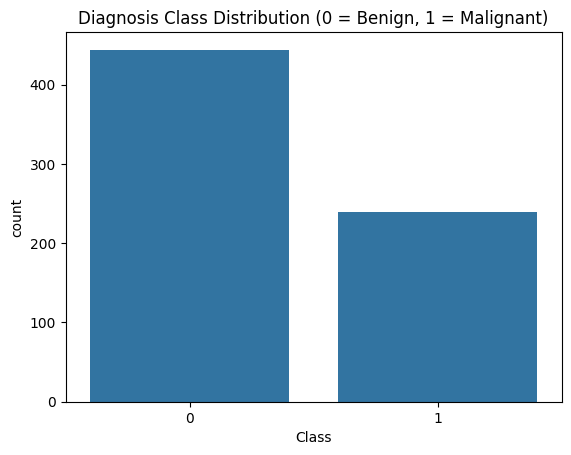

In [8]:
# Visualize Class Distribution
sns.countplot(x='Class', data=df)
plt.title("Diagnosis Class Distribution (0 = Benign, 1 = Malignant)")
plt.show()

## **6.2 : Use the C5.0 methodology to develop a classification model for the Diagnosis**

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Create and train the Decision Tree model
tree_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [11]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       127
           1       0.97      0.92      0.95        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.96       205
weighted avg       0.96      0.96      0.96       205



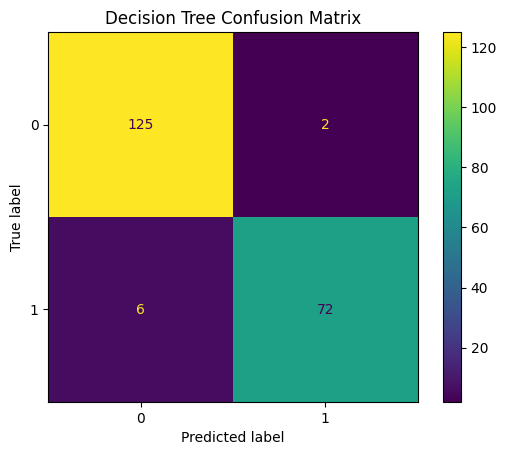

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree Confusion Matrix")
plt.show()